# Métricas de Clasificación

**Integrante 1:** Claudio Gaete Flores
**Integrante 2:** Juan Loyola Lagos

**Correo Electrónico Integrante 1:** claudio.gaete2301@alumnos.ubiobio.cl
**Correo Electrónico Integrante 2:** juan.loyola2301@alumnos.ubiobio.cl

**Fecha de Creación:** 27 de Mayo de 2026  
**Versión:** 1.0  

---

## Descripción

Este notebook contiene el desarrollo de la evaluación 2 de la asignatura de Inteligencia Artificial 620454 Sección 1. Donde, en base a un contexto de negocio y un dataset, se crean y entrenan modelos predictivos y se comparan sus índices para seleccionar el mejor.

---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)


Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)
````

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, FunctionTransformer, StandardScaler

from sklearn.base import BaseEstimator, TransformerMixin

# Carga de Datos

## Descripción datos

El dataset de estudio contiene la información semanal de diferentes tiendas de retail en diferentes años\. Este dataset guarda elementos como:

- Características de la tienda

- Contexto o variables externas de la tienda

- Variables temporales de la semana

- Demanda semanal de la tienda\.

In [2]:
data = pd.read_csv('../data/ingestion/retail_ventas.csv')
data.head()

,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda,ventas_semanales
0,86,1445.454837,1,2.611389,0.925557,97.313562,41,0,376.608869,B,40377.989406
1,35,1973.195744,18,5.603718,1.526210,88.821903,52,0,197.329419,A,59430.330077
2,41,1727.496264,24,7.330847,1.297304,109.273193,15,0,262.737637,A,56547.323925
3,97,1284.634121,10,16.074751,0.862449,98.362477,45,0,392.171919,A,36408.752020
4,25,1457.596546,5,9.278104,1.264497,92.081812,45,0,411.085409,B,40500.513890


In [3]:
data.shape

(25500, 11)

In [4]:
data.columns

Index(['id_tienda', 'tamano_tienda', 'antiguedad_tienda', 'temperatura',
       'precio_combustible', 'indice_economico', 'semana', 'es_feriado',
       'clientes_estimados', 'tipo_tienda', 'ventas_semanales'],
      dtype='object')

## Objetivo

El objetivo de este trabajo es crear y comparar modelos predictivos de las ventas semanales de una tienda basándose en sus características, contexto externo, etc\.

### Variables Numéricas

- id\_tienda: identificador único de la tienda \(discreta\)

- tamano\_tienda: tamaño de la tienda en metros cuadrados

- antiguedad\_tienda: años desde su apertura

- temperatura: temperatura promedio semanal \(°C\) 

- precio\_combustible: precio promedio del combustible 

- indice\_economico: indicador económico general \(similar al CPI\)

- semana: número de semana del año \(1–52\) \(discreta\)

- es\_feriado: indica si la semana contiene un feriado \(1 = sí, 0 = no\)\(discreta\)

- clientes\_estimados: número estimado de clientes en la semana

### Variables Categóricas

- tipo\_tienda: categoría de la tienda \(Ordinal\)

- A: tiendas grandes con alta demanda

- B: tiendas medianas

- C: tiendas pequeñas

# Fase 2 - Entendimiento de los datos

Primero, debemos entender que nuestra variable objetivo son las ventas semanales\. Por esto,  analizamos la dispersión de esta variable con un histograma\.

Al generar el gráfico, notamos una simetría o un sesgo positivo\. En otras palabras, las ventas semanales tienden a ser menores que el promedio\.

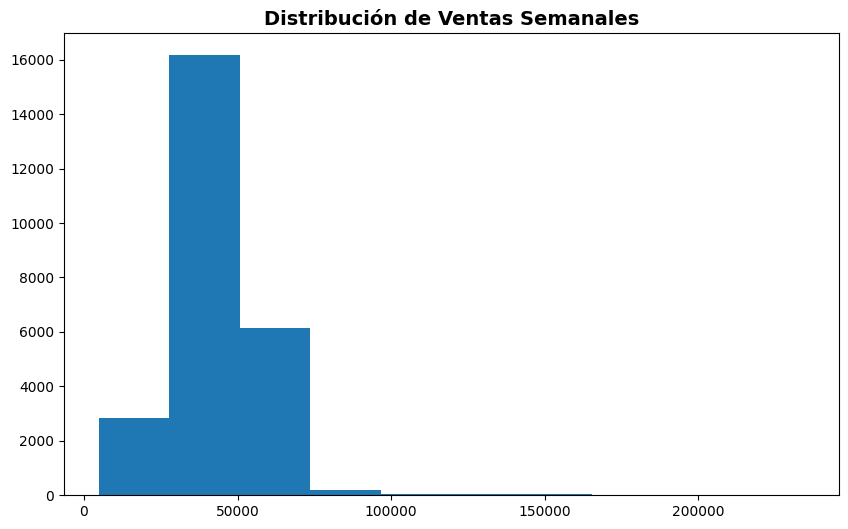

In [5]:
data.ventas_semanales.hist(bins=10, figsize=(10,6), grid=False)
plt.title("Distribución de Ventas Semanales", fontsize=14, fontweight="bold")
plt.show()

In [6]:
data.ventas_semanales.describe()

count     25500.000000
mean      43108.586339
std       14538.319334
min        4905.208771
25%       33827.197346
50%       42117.538361
75%       50947.405475
max      234175.036973
Name: ventas_semanales, dtype: float64

## Detección de inconsistencias

Para definir las inconsistencias, primero debemos definir cuándo los datos cuantitativos consistentes:

- tamano\_tienda: Al representar un área en metros cuadrados, este debe ser un valor positivo \(mayor que cero\)

- antiguedad\_tienda: Al representar el tiempo en años, este debe ser positivo

- precio\_combustible: Al ser un valor monetario, debe ser mayor que cero

- semana: Su valor debe estar en el rango 1\-52 \(semanas en un año\)

- es\_feriado: Su valor debe ser 1 o 0\.

- clientes\_estimados: La estimación debe ser un número positivo al contar personas\.

- ventas\_semanales: Al ser un valor monetario, debe ser positivo\.

Al ejecutar el código para encontrar inconsistencias, este no nos arroja resultados\. Por lo que los datos cuantitativos del dataset son consistentes\.

In [7]:
# Detectar inconsistencias
inconsistentes = data[
    (data["tamano_tienda"] <= 0) | 
    (data["antiguedad_tienda"] <= 0) | 
    (data["precio_combustible"] <= 0) | 
    (data["semana"] < 1) | (data["semana"] > 52) |
    (data["es_feriado"] < 0) | (data["es_feriado"] > 1) |
    (data["clientes_estimados"] <= 0) |
    (data["ventas_semanales"] <= 0)
]
print("Registros inconsistentes encontrados:")
display(inconsistentes)

Registros inconsistentes encontrados:


,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda,ventas_semanales


Para la variable categórica "tipo\_tienda", analizamos sus valores únicos\.

Al ejecutar el código, vemos que los valores únicos son "A", "B" y "C"\. Valores que se encuentran dentro del rango de las categorías de las tiendas\.

In [8]:
data.tipo_tienda.unique()

array(['B', 'A', 'C'], dtype=object)

## Detección de nulos

Debemos analizar la existencia de valores nulos en el dataset\. Con el propósito de analizar si es necesario imputar datos en la fase de limpieza\.

Al ejecutar el código, vemos que:

- temperatura: tiene 1276 valores nulos\.

- precio\_combustible: tiene 1279 nulos

- clientes\_estimados: tiene 1280 nulos

El cálculo de estos valores se basa en restar la cantidad de tuplas \(25500\) con la cantidad de valores no nulos de una variable\.

Con este análisis, sabemos que debemos imputar estos valores en la limpieza de datos antes de preparar el modelo\.

In [9]:
print("Información de valores nulos y tipos de datos:")
data.info()

Información de valores nulos y tipos de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25500 entries, 0 to 25499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_tienda           25500 non-null  int64  
 1   tamano_tienda       25500 non-null  float64
 2   antiguedad_tienda   25500 non-null  int64  
 3   temperatura         24224 non-null  float64
 4   precio_combustible  24221 non-null  float64
 5   indice_economico    25500 non-null  float64
 6   semana              25500 non-null  int64  
 7   es_feriado          25500 non-null  int64  
 8   clientes_estimados  24220 non-null  float64
 9   tipo_tienda         25500 non-null  object 
 10  ventas_semanales    25500 non-null  float64
dtypes: float64(6), int64(4), object(1)
memory usage: 2.1+ MB


## Detección de valores atípicos

También debemos analizar la existencia de valores atípicos en las variables cuantitativas en estudio\.

Al ejecutar el código, notamos que las variables con valores nulos  "temperatura", "precio\_combustible" y "clientes\_estimados" tienen valores atípicos\. Como imputaremos los nulos por la media y esta debe ser representativa, entonces debemos tratar estos valores\.

Para las otras variables con atípicos \(tamano\_tienda e indice\_economico\), debemos considerar que entrenaremos los modelos con regresión lineal y con Ridge\. Como estos algoritmos son sensibles a los atípicos, entonces debemos tratar estos\.

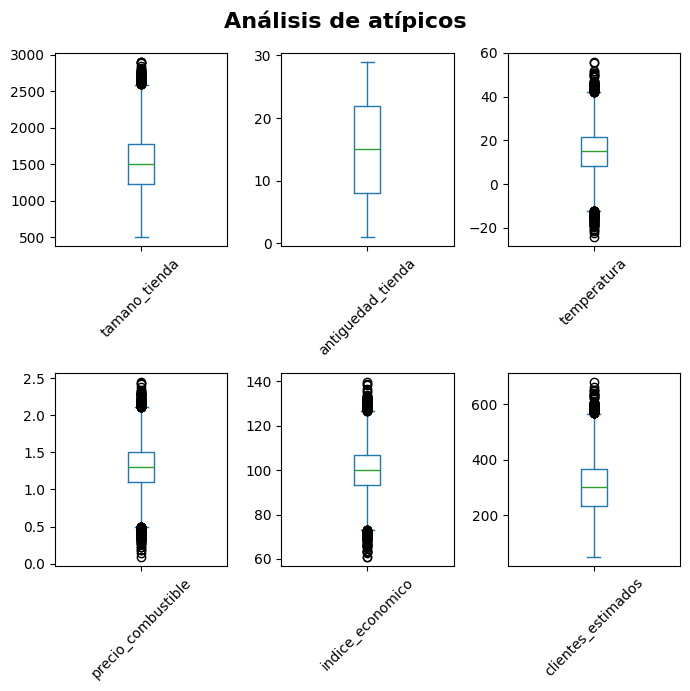

In [10]:
revision_atipicos = ['tamano_tienda', 'antiguedad_tienda', 'temperatura',	
                    'precio_combustible', 'indice_economico', 'clientes_estimados'
]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()  # convierte la matriz de ejes en un vector
for i, col in enumerate(revision_atipicos):
  data[col].plot(kind='box',figsize=(7,7), ax=axes[i])
  axes[i].tick_params(axis="x", labelrotation=45)

plt.suptitle("Análisis de atípicos", fontsize=16, fontweight="bold")
plt.tight_layout()

plt.show()

## Detección de duplicados

También debemos analizar la existencia de duplicados\. Aunque no haya un identificador de registro en el dataset, se puede construir uno usando las variables id\_tienda \(identifica tienda\), semana y antiguedad\_tienda \(indica implícitamente el año de la semana\)\. Por esto, no debería ser posible tener dos filas iguales\.

Al ejecutar el código, vemos que existen 494 filas duplicadas\. Por lo que debemos tratar estas para evitar sesgos en los modelos\.

In [11]:
# Revisa la existencia de duplicados
data.duplicated().sum()

494

In [12]:
# Obtiene los registos duplicados
data[data.duplicated(keep=False)].sort_values(by='id_tienda')

,id_tienda,tamano_tienda,antiguedad_tienda,temperatura,precio_combustible,indice_economico,semana,es_feriado,clientes_estimados,tipo_tienda,ventas_semanales
25472,1,1662.308696,4,8.021267,1.358711,100.793627,1,0,208.593492,B,50334.268750
1886,1,2034.754785,10,14.208497,0.938566,89.582706,17,0,291.469835,C,43551.521560
1863,1,1775.899028,8,5.290492,1.161663,83.668164,16,0,NaN,B,34000.945523
25102,1,1252.640455,15,29.661292,1.227838,78.345011,43,0,409.599646,A,44015.038688
2085,1,1509.188138,15,20.742301,0.938181,81.498404,26,0,294.889363,C,27900.094111
...,...,...,...,...,...,...,...,...,...,...,...
5088,100,611.630993,17,23.214253,0.962835,80.465318,21,0,351.873700,A,27753.376425
25435,100,611.630993,17,23.214253,0.962835,80.465318,21,0,351.873700,A,27753.376425
12958,100,1791.584326,21,31.701831,1.451529,95.250365,9,0,406.231342,C,47408.979071
25425,100,1791.584326,21,31.701831,1.451529,95.250365,9,0,406.231342,C,47408.979071


# Fase 3 - Preparación de datos

## Definición de variables de predicción y objetivo

Debemos separar qué variables son candidatas para crear el modelo predictivo \(X\) y la variable objetivo que queremos predecir \(Y\)\.

En este caso, nuestra variable a predecir es ventas\_semanales, mientras que las variables predictoras serán el resto de las variables menos el identificador de tienda \(id\_tienda\)\.

## Definición de clases de limpieza de datos

### Tratamiento de atípicos

La clase Winsorizer nos ayuda en el tratamiento de atípicos al limitar estos al percentil 5 y al percentil 95 para los valores más bajos y altos respectivamente\. De esta manera, reducimos los atípicos y mejoramos la representatividad de la media\.

In [13]:
class Winsorizer(BaseEstimator, TransformerMixin):
  """
  Tratamiento de atípicos

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_ : array-like
    Nombres de las columnas a transformar.
  limits : tuple
    % de los extremos a descartar
  """
  def __init__(self, limits=(0.05, 0.05)):
    self.limits = limits

  def fit(self, X, y=None):
    # Guardar nombres si es DataFrame, si no generar nombres genéricos
    if isinstance(X, pd.DataFrame):
      self.columns_ = X.columns
    else:
      self.columns_ = np.arange(X.shape[1])
    return self

  def transform(self, X):
    X = pd.DataFrame(X, columns=self.columns_)
    for col in self.columns_:
      lower = X[col].quantile(self.limits[0])
      upper = X[col].quantile(1 - self.limits[1])
      X = X.astype("float64")
      X[col] = np.clip(X[col], lower, upper)
    return X

  def get_feature_names_out(self, input_features=None):
    if input_features is None:
      return np.array(self.columns_)
    else:
      return np.array(input_features)

### Tratamiento de duplicados

Para los duplicados, usaremos una función en donde se eliminan estas tuplas si "drop" es true\. De esta manera, eliminamos posibles sesgos en el modelo\.

In [14]:
def tratar_duplicados(X : pd.DataFrame, drop = True):
  """
  Tratamiento de duplicados

  Parámetros
  ----------
  X : DataFrame
    Conjunto de datos.
  drop : bool
    Si se deben eliminar los duplicados.

  Retorna
  -------
  DataFrame
    Conjunto de datos sin duplicados.
  """
  return X.drop_duplicates() if drop else X

### Tratamiento de variables correlacionadas

Esta clase elimina las variables que se encuentren muy relacionadas \(90% de correlación\)\. De esta manera, eliminamos cierta redundancia y nos permite elegir mejor las variables predictoras\.

In [15]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
  """
  Eliminación de variables correlacionadas

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  columns_to_drop_ : array-like
    Nombres de las columnas a eliminar.
  threshold : float
    Umbral de correlación.
  Returns
  -------
  DataFrame
    Conjunto de datos sin variables correlacionadas.
  """
  def __init__(self, threshold=0.9):
    self.threshold = threshold
    self.columns_to_drop_ = None

  def fit(self, X, y=None):
    X_df = pd.DataFrame(X)

    corr_matrix = X_df.corr().abs()
    upper = corr_matrix.where(
      np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    self.columns_to_drop_ = [
        col for col in upper.columns if any(upper[col] > self.threshold)
    ]

    return self

  def transform(self, X):
    X_df = pd.DataFrame(X)
    X_filtered = X_df.drop(columns=self.columns_to_drop_, errors="ignore")
    return X_filtered.values

## Definición de función de ingeniería de características

Esta clase nos permite añadir variables a partir de otras, las cuales, por sí solas, no sean buenas predictoras\.

In [16]:
def feature_engineering(data: pd.DataFrame):
    """
        Realiza ingeniería de características

        Parámetros
        ----------
        data: DataFrame conteniendo los datos

        Retorno
        -------
        DataFrame con las nuevas características:
            densidad_clientes: Indica que tan apretados se encuentran los clientes en una tienda
            semana_especial: indica si la semana es especial (1 sí, 0 no) según si es navidad, pascua, etc.
    """
    X = data.copy()
    X["densidad_clientes"] = X["clientes_estimados"] / X["tamano_tienda"]
    return X

## Definición de clase transformadora de DataFrame

Como el Pipeline transforma el dataset en un arreglo, con esta clase lo volvemos a transformar en un DataFrame

In [17]:
class DataFrameConverter(BaseEstimator, TransformerMixin):
  """
  Convierte un array en un DataFrame

  Parámetros
  ----------
  BaseEstimator : Clase base para estimadores en scikit-learn.
  TransformerMixin : Clase base para transformadores en scikit-learn.

  Atributos
  ---------
  feature_names_ : array-like
    Nombres de las columnas.
  Returns
  -------
  DataFrame
    Conjunto de datos con nombres de columnas.
  """
  def __init__(self, preprocessor):
    self.preprocessor = preprocessor
    self.feature_names_ = None

  def fit(self, X, y=None):
    # Obtener nombres después de fit del preprocessor
    self.feature_names_ = self.preprocessor.get_feature_names_out()
    return self

  def transform(self, X):
    return pd.DataFrame(X, columns=self.feature_names_)

## Definición de pipeline de limpieza transformación variables predictoras

Separamos esta etapa en el Pipeline que tratará las variables cuantitativas de las variables cualitativas\.

- Para las cuantitativas, primero winsorizamos los atípicos, luego imputamos los nulos por la media \(valor representativo\) y aplicamos la transformación con distribución estándar

- Para la variable cualitativa, las codificamos con OrdinalEncoder, o sea, cada categoría pasa a ser un número con 0 = C, 1 = B y 2 = A\. También, la transformaremos para que tenga la misma escala que el resto de variables cuantitativas\.

In [18]:
# Preprocesamiento numérico: winsorizacion + imputación con media + estandarización
numeric_transformer = Pipeline(steps=[
    ("winsorizer", Winsorizer()),
    ("imputer", SimpleImputer(strategy="mean")),
    ("escalado", StandardScaler())
])

# Preprocesamiento categórico: ordinal encoding + estandarización
categorical_transformer = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(categories=[['C','B','A']])),
    ("escalado", StandardScaler())
])

## Evaluación de las mejores variables predictoras

Debemos analizar qué variables podrían predecir mejor la variable objetivo\. Para esto, analizamos su correlatividad con ventas\_semanales\. Además, codificamos la variable categórica para poder hacer el análisis de correlación\. También, diremos que una variable es buena candidata cuando su correlación absoluta es mayor al 40%\.

Al ejecutar el código, vemos que las únicas variables predictoras buenas son:

- tamano\_tienda con una correlación del 59\.34%, o sea, a mayor tamaño, más ventas tendrá la tienda\.

- tipo\_tienda codificado con un 43\.86% de correlación, o sea, mientras más grande la tienda \(tipo A\), más ingresos percibe\.

In [19]:
target = 'ventas_semanales'

encoder = OrdinalEncoder(categories=[['C','B','A']])
tipo_tienda_encoded = encoder.fit_transform(data[["tipo_tienda"]])

data_ohe = pd.DataFrame(tipo_tienda_encoded, columns=encoder.get_feature_names_out())

data_corr = pd.concat([data, data_ohe], axis=1)

data_corr.corr(numeric_only=True)[target]

id_tienda             0.005966
tamano_tienda         0.593410
antiguedad_tienda    -0.000979
temperatura          -0.000746
precio_combustible    0.001026
indice_economico      0.042103
semana               -0.010844
es_feriado            0.107034
clientes_estimados    0.111599
ventas_semanales      1.000000
tipo_tienda           0.438616
Name: ventas_semanales, dtype: float64

Al analizar los promedios de ventas de cada categoría de tiendas, notamos la misma tendencia donde, mientras más grande es la tienda \(tipo A\), más ventas tiene\.

In [20]:
data.groupby("tipo_tienda")[target].mean().sort_values()

tipo_tienda
C    32657.412613
B    40586.519400
A    48878.116968
Name: ventas_semanales, dtype: float64

Finalmente, al agregar las columnas de ingeniería de características, vemos que "densidad\_clientes" presenta una correlación del \-30\.17%, es decir, mientras más "apretados" los clientes, menos ventas percibe la tienda\. Aunque esta presenta menor correlación absoluta que el umbral establecido \(40%\)

In [21]:
# Agrega las nuevas columnas para analizar su correlación con la variable objetivo
data_corr = feature_engineering(data_corr)
data_corr.corr(numeric_only=True)[target]

id_tienda             0.005966
tamano_tienda         0.593410
antiguedad_tienda    -0.000979
temperatura          -0.000746
precio_combustible    0.001026
indice_economico      0.042103
semana               -0.010844
es_feriado            0.107034
clientes_estimados    0.111599
ventas_semanales      1.000000
tipo_tienda           0.438616
densidad_clientes    -0.301676
Name: ventas_semanales, dtype: float64

Finalmente, mantendremos como variables predictoras aquellas que tengan una correlación absoluta mayor al 4%\. Lo que descarta otras como la temperatura, la antigüedad de la tienda, el precio del combustible y la semana\. También, descartamos la variable "id\_tienda" al ser solo un identificador y no tener correlación con la variable objetivo\.

# Fase 4 - Modelamiento

Para nuestros modelos, elegimos las variables con mejor correlación y los construimos a partir de estas\. Es importante destacar que a pesar de que algunas variables no presenten una correlación visible igualmente afectan o tienen alguna relación con las ventas semanales, como por ejemplo "es\_feriado":

In [22]:
# Variables
features_num = ["tamano_tienda","indice_economico", "es_feriado",
    "clientes_estimados"
]
features_cat = ["tipo_tienda"]
target = "ventas_semanales"

# Variables independientes
X = data[features_num + features_cat]
# Variable objetivo
y = data[target]

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, features_num),
        ("cat", categorical_transformer, features_cat)
    ]
)

A continuación se crean 4 modelos distintos en conjunto del Pipeline creado anteriormente\. El modelo de regresión lineal, el modelo ridge con alpha = 0, modelo ridge con alpha = 3 y modelo ridge con alpha = 100\.

### Pipeline de preparación de datos

In [24]:
# Crea el pipeline que prepara los datos para el modelo
preparado = Pipeline(steps=[
    ("duplicados", FunctionTransformer(tratar_duplicados,
                                       kw_args={"drop": False})),
    ("feature_engineering", FunctionTransformer(feature_engineering)),
    ("preprocesador", preprocessor),
    ("imputer", SimpleImputer(strategy="mean")), #para feauture_engineering
    ("conversion", DataFrameConverter(preprocessor)),
    ("colinealidad", CorrelationFilter(threshold=0.9))
])

### Guardado de datos limpios

In [25]:
X_clean = preparado.fit_transform(X)
data_clean = pd.DataFrame(
    X_clean,
    columns=preparado.named_steps["preprocesador"].get_feature_names_out()
)
data_clean['ventas_semanales'] = y
data_clean.to_csv('../data/cleaned/retail_ventas_cleaned.csv')

## Modelo de Regresión Lineal

In [26]:
# Crea el pipeline final (preprocesamiento + modelo)
modelo_regresion_lineal = Pipeline(steps=[
    ("preparado", preparado),
    ("modelo", LinearRegression())
])

## Modelo Ridge

El modelo Ridge se caracteriza por contar con un coeficiente de penalización Alpha el cual penaliza a las variables predictoras que cuenten con un menor peso\. Lo que ayuda a controlar la colinealidad entre predictoras y evita que las variables con menos peso influyan más en la predicción\.

Para este trabajo, tomaremos tres modelos Ridge con diferentes parámetros de Alpha

### α = 0 \(Regresión Lineal\)

Para este modelo su penalización es nula\. Por lo que, en teoría, debe comportarse como un modelo de regresión lineal

In [27]:
modelo_ridge_0 = Pipeline([
    ("preparado", preparado),
    ("modelo", Ridge(alpha=0.0))
])

### α = 3, penalización leve

Para este ejemplo, se da una penalización pequeña a las variables con menos peso\.

In [28]:
modelo_ridge_3 = Pipeline([
    ("preparado", preparado),
    ("modelo", Ridge(alpha=3.0))
])

### α = 100, penalización severa

El modelo se comporta como si ignorara las variables con menos peso en la predicción\. Aunque no lo hace del todo\.

In [29]:
modelo_ridge_100 = Pipeline([
    ("preparado", preparado),
    ("modelo", Ridge(alpha=100.0))
])

## Entrenamiento de modelos

Ahora se declaran las variables usadas para el entrenamiento de los modelos, usamos un random\_state aleatorio y un test\_size de 20%\. Ees decir se guardaran un 20% de los datos con el fin de evaluar la predictibilidad de los modelos y así poder obtener sus métricas respectivas \(R2 y MAE\), mientras que el 80% se usa para entrenar el modelo\.

In [30]:
# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2, random_state=59)

### Entrenamiento regresión lineal

In [31]:
# Entrenamiento
modelo_regresion_lineal.fit(X_train, y_train)

Pipeline(steps=[('preparado',
                 Pipeline(steps=[('duplicados',
                                  FunctionTransformer(func=<function tratar_duplicados at 0x7feed05f14e0>,
                                                      kw_args={'drop': False})),
                                 ('feature_engineering',
                                  FunctionTransformer(func=<function feature_engineering at 0x7feed05f1d00>)),
                                 ('preprocesador',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('winsorizer',
                                                                                    Winsorizer()),
                                                                                   (...
                                                                                                   Pipeline(steps=[('winsorizer',
                                                                                                                    Winsorizer()),
                                                                                                                   ('imputer',
                                                                                                                    SimpleImputer()),
                                                                                                                   ('escalado',
                                                                                                                    StandardScaler())]),
                                                                                                   ['tamano_tienda',
                                                                                                    'indice_economico',
                                                                                                    'es_feriado',
                                                                                                    'clientes_estimados']),
                                                                                                  ('cat',
                                                                                                   Pipeline(steps=[('ordinal',
                                                                                                                    OrdinalEncoder(categories=[['C',
                                                                                                                                                'B',
                                                                                                                                                'A']])),
                                                                                                                   ('escalado',
                                                                                                                    StandardScaler())]),
                                                                                                   ['tipo_tienda'])]))),
                                 ('colinealidad', CorrelationFilter())])),
                ('modelo', LinearRegression())])

### Entrenamiento Ridge \(α = 0\)

In [32]:
# Entrenamiento
modelo_ridge_0.fit(X_train, y_train)

Pipeline(steps=[('preparado',
                 Pipeline(steps=[('duplicados',
                                  FunctionTransformer(func=<function tratar_duplicados at 0x7feed05f14e0>,
                                                      kw_args={'drop': False})),
                                 ('feature_engineering',
                                  FunctionTransformer(func=<function feature_engineering at 0x7feed05f1d00>)),
                                 ('preprocesador',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('winsorizer',
                                                                                    Winsorizer()),
                                                                                   (...
                                                                                                   Pipeline(steps=[('winsorizer',
                                                                                                                    Winsorizer()),
                                                                                                                   ('imputer',
                                                                                                                    SimpleImputer()),
                                                                                                                   ('escalado',
                                                                                                                    StandardScaler())]),
                                                                                                   ['tamano_tienda',
                                                                                                    'indice_economico',
                                                                                                    'es_feriado',
                                                                                                    'clientes_estimados']),
                                                                                                  ('cat',
                                                                                                   Pipeline(steps=[('ordinal',
                                                                                                                    OrdinalEncoder(categories=[['C',
                                                                                                                                                'B',
                                                                                                                                                'A']])),
                                                                                                                   ('escalado',
                                                                                                                    StandardScaler())]),
                                                                                                   ['tipo_tienda'])]))),
                                 ('colinealidad', CorrelationFilter())])),
                ('modelo', Ridge(alpha=0.0))])

### Entrenamiento Ridge \(α = 3\)

In [33]:
# Entrenamiento
modelo_ridge_3.fit(X_train, y_train)

Pipeline(steps=[('preparado',
                 Pipeline(steps=[('duplicados',
                                  FunctionTransformer(func=<function tratar_duplicados at 0x7feed05f14e0>,
                                                      kw_args={'drop': False})),
                                 ('feature_engineering',
                                  FunctionTransformer(func=<function feature_engineering at 0x7feed05f1d00>)),
                                 ('preprocesador',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('winsorizer',
                                                                                    Winsorizer()),
                                                                                   (...
                                                                                                   Pipeline(steps=[('winsorizer',
                                                                                                                    Winsorizer()),
                                                                                                                   ('imputer',
                                                                                                                    SimpleImputer()),
                                                                                                                   ('escalado',
                                                                                                                    StandardScaler())]),
                                                                                                   ['tamano_tienda',
                                                                                                    'indice_economico',
                                                                                                    'es_feriado',
                                                                                                    'clientes_estimados']),
                                                                                                  ('cat',
                                                                                                   Pipeline(steps=[('ordinal',
                                                                                                                    OrdinalEncoder(categories=[['C',
                                                                                                                                                'B',
                                                                                                                                                'A']])),
                                                                                                                   ('escalado',
                                                                                                                    StandardScaler())]),
                                                                                                   ['tipo_tienda'])]))),
                                 ('colinealidad', CorrelationFilter())])),
                ('modelo', Ridge(alpha=3.0))])

### Entrenamiento Ridge \(α = 100\)

In [34]:
# Entrenamiento
modelo_ridge_100.fit(X_train, y_train)

Pipeline(steps=[('preparado',
                 Pipeline(steps=[('duplicados',
                                  FunctionTransformer(func=<function tratar_duplicados at 0x7feed05f14e0>,
                                                      kw_args={'drop': False})),
                                 ('feature_engineering',
                                  FunctionTransformer(func=<function feature_engineering at 0x7feed05f1d00>)),
                                 ('preprocesador',
                                  ColumnTransformer(transformers=[('num',
                                                                   Pipeline(steps=[('winsorizer',
                                                                                    Winsorizer()),
                                                                                   (...
                                                                                                   Pipeline(steps=[('winsorizer',
                                                                                                                    Winsorizer()),
                                                                                                                   ('imputer',
                                                                                                                    SimpleImputer()),
                                                                                                                   ('escalado',
                                                                                                                    StandardScaler())]),
                                                                                                   ['tamano_tienda',
                                                                                                    'indice_economico',
                                                                                                    'es_feriado',
                                                                                                    'clientes_estimados']),
                                                                                                  ('cat',
                                                                                                   Pipeline(steps=[('ordinal',
                                                                                                                    OrdinalEncoder(categories=[['C',
                                                                                                                                                'B',
                                                                                                                                                'A']])),
                                                                                                                   ('escalado',
                                                                                                                    StandardScaler())]),
                                                                                                   ['tipo_tienda'])]))),
                                 ('colinealidad', CorrelationFilter())])),
                ('modelo', Ridge(alpha=100.0))])

# Evaluación de modelos

Una vez entrenados los modelos, podemos evaluar el coeficiente de determinación \(R2\) y el error absoluto medio \(MAE\) para cada modelo\.

## Modelo LinearRegression 

In [35]:
y_pred = modelo_regresion_lineal.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo de regresion lineal---")
print(f"{'R2':<6}: {r2:.5f}")
print(f"{'MAE':<6}: {mae:.3f}")
y_pred.round(3)


--- Métricas del modelo de regresion lineal---
R2    : 0.58752
MAE   : 5038.760


array([46168.395, 49242.733, 49167.532, ..., 44851.55 , 60258.837,
       53639.109])

Para el modelo de regresión lineal obtenemos un R2 de 58\.75% y MAE de 5038\.7, lo que significa que este modelo logra explicar el 58\.75% de las ventas totales y su predicción posee un error absoluto medio de aproximadamente $5\.038\.700 pesos \(suponiendo que las ventas semanales se miden en miles de pesos\)\. Teniendo en cuenta que las ventas semanales rondan los $50 millones de pesos podemos decir que el modelo posee un margen de error promedio de cerca del 10%\.

## Modelo Ridge \(alpha = 0\)

In [36]:
y_pred = modelo_ridge_0.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo ridge (alpha = 0) ---")
print(f"{'R2':<6}: {r2:.5f}")
print(f"{'MAE':<6}: {mae:.3f}")
y_pred.round(33)


--- Métricas del modelo ridge (alpha = 0) ---
R2    : 0.58752
MAE   : 5038.760


array([46168.39460578, 49242.73295466, 49167.53233011, ...,
       44851.54994229, 60258.83661224, 53639.10918437])

Para el modelo Ridge con alpha 0, también obtenemos un R2 de 58\.75% y MAE de 5038\.7\. Esto nos dice que un modelo de regresión lineal es equivalente a un modelo Ridge sin penalización\. A partir de esto podemos deducir que un modelo de regresión lineal no castiga a las variables independientes con una baja correlación\.

## Modelo Ridge \(alpha = 3\)

In [37]:
y_pred = modelo_ridge_3.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo ridge (alpha = 3) ---")
print(f"{'R2':<6}: {r2:.5f}")
print(f"{'MAE':<6}: {mae:.3f}")
y_pred.round(3)


--- Métricas del modelo ridge (alpha = 3) ---
R2    : 0.58752
MAE   : 5038.733


array([46167.954, 49241.826, 49166.654, ..., 44851.297, 60256.307,
       53637.593])

Para el modelo Ridge con alpha 3 también obtenemos un R2 de 58\.75% y MAE de 5038\.7, es decir una penalización muy baja no influye significativamente en este caso\. Esto se puede explicar porque en lugar de entrenar el modelo con todas las variables, se han elegido las que tengan mayor correlación\.

## Modelo Ridge \(alpha = 100\)

In [38]:
y_pred = modelo_ridge_100.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Métricas del modelo ridge (alpha = 100) ---")
print(f"{'R2':<6}: {r2:.5f}")
print(f"{'MAE':<6}: {mae:.3f}")
y_pred.round(3)


--- Métricas del modelo ridge (alpha = 100) ---
R2    : 0.58754
MAE   : 5037.977


array([46153.775, 49212.654, 49138.379, ..., 44843.173, 60174.91 ,
       53588.803])

En cuanto al modelo Ridge con alpha 100, nos ha dado un R2 de 58\.7% y un MAE de 5037\.9, es decir, un error absoluto medio de aproximadamente $5\.037\.900\. Esto supone una leve mejora respecto a los modelos anteriores, lo que se puede explicar gracias al aumento de la variable alpha, que significa una penalización mayor a variables de baja correlación\.

## Conclusiones evaluación\.

El propósito de estos modelos es predecir las ventas de las sucursales de las tiendas de retail\. De esta manera, las tiendas pueden mejorar su planificación operativa y logística al optimizar el inventario, planificar las campañas promocionales y ajustar los recursos según la demanda esperada\.

Volviendo a los indicadores, el MAE indica el margen de error en las predicciones\. Por lo que se busca minimizar este margen al estar hablando de dinero, donde cada cifra cuenta aunque sea pequeña\.

Por lo anterior, el modelo seleccionado como el mejor ha sido el Modelo Ridge con alpha = 100\. Esto porque presenta el índice MAE menor en comparación con los otros modelos\.

## Sobre la colinealidad entre variables\.

Una razón por la que el modelo Ridge no se diferenció del modelo de regresión lineal es por la ausencia de una colinealidad clara entre variables predictoras\. Esta idea se refuerza con que, en el preparado de datos, no hubo variables eliminadas por presentar colinealidad sobre el 90%\.

In [39]:
# Variables que fueron eliminadas por presentar colinealidad
preparado.named_steps["colinealidad"].columns_to_drop_

[]

# Interpretación de Resultados

A la hora de elegir el modelo Ridge con alpha=100, cuando analizamos las variables más influyentes como vimos en la sección de "Evaluación de las mejores variables predictoras", estas son las que tienen mayor correlación con la variable objetivo \(ventas\_semanales\):

- tamano\_tienda con 59\.34% de correlación\. Lo que implica que, mientras más grande físicamente sea la tienda, más ventas percibe\.

- tipo\_tienda \(codificado de C a A\) con 43\.86%\. Es decir, mientras más grande y demandada sea la tienda \(más cerca de A\), más ventas percibe\. Esto se refuerza con el análisis del promedio de las ventas por cada categoría\.

- densidad\_clientes con \-30\.17%\. Lo que detalla un fenómeno de trade\-off donde, mientras más densa esté la tienda con clientes, menos ventas percibe\.

# Predicción de ventas semanales

Para probar el modelo seleccionado, haremos tres predicciones de prueba con registros nuevos de tiendas:

- Tienda con ID 15:

- 1000 metros cuadrado de tamaño con 3 años de antigüedad

- temperatura de 12° y precio combustible de 1\.5 \(semanal promedio\)

- índice económico de 109

- ventas en la semana 3 y sin feriados

- estimación de 60 clientes

- Tienda de categoría C

- Tienda con ID 78:

- 800 metros cuadrado de tamaño con 4 años de antigüedad

- temperatura de \-3° y precio combustible de 0\.98 \(semanal promedio\)

- índice económico de 92

- ventas en la semana 28 y con feriados

- estimación de 98 clientes

- Tienda de categoría B

- Tienda con ID 23:

- 1500 metros cuadrado de tamaño con 10 años de antigüedad

- temperatura de 22° y precio combustible de 1\.2 \(semanal promedio\)

- índice económico de 120

- ventas en la semana 11 y sin feriados

- estimación de 302 clientes

- Tienda de categoría A

Al predecir, veremos que:

- La primera tienda tendrá unas ventas semanales de 16999\.346\. Resultado probablemente influenciado por el tamaño de su sucursal\.

- La segunda tienda tendrá ventas de 33159\.31\. Aunque sea la sucursal más pequeña, la categoría tipo A influye en las ventas\.

- La tercera sucursal tendrá ventas de 40061\.011\. Probablemente la diferencia de ventas con las otras ventas se deba al ser la sucursal de mayor tamaño\.

In [40]:
X_data = pd.DataFrame({
    "id_tienda": [15, 78, 23],
    "tamano_tienda": [1000, 800, 1500],
    "antiguedad_tienda": [3, 4, 10],
    "temperatura": [12, -3, 22],
    "precio_combustible": [1.5, 0.98, 1.2],
    "indice_economico": [109, 92, 120],
    "semana": [3, 29, 11],
    "es_feriado": [0, 1, 0],
    "clientes_estimados": [60, 98, 302],
    "tipo_tienda": ['C', 'A', 'B']
})
print("Prediccion con Ridge (alpha=100): ")
modelo_ridge_100.predict(X_data).round(3)

Prediccion con Ridge (alpha=100): 


array([16999.346, 33159.31 , 40061.011])

# Reflexión

Después de haber hecho las pruebas, podemos apreciar las diferencias entre los modelos entrenados anteriormente\. En primer lugar, para ambos tipos de modelos se destacan métricas un poco distantes de las deseadas para un modelo predictivo\. Para el modelo de regresión lineal obtenemos un coeficiente de determinación \(R2\) de 58,7% y un error absoluto medio \(MAE\) de 5038, si comparamos estas métricas con el modelo Ridge con alpha = 0, notamos que son prácticamente iguales, incluso para las predicciones con datos nuevos\. Esto nos da a entender que un modelo de regresión lineal es un modelo Ridge sin "penalización"\. Para el caso del modelo Ridge con alpha = 3, notamos un leve cambio en las predicciones y métricas muy similares\. Finalmente para el modelo Ridge con alpha = 100 notamos una mejora en las métricas con una leve disminución en el MAE, esto nos dice que la penalización severa ayuda a disminuir el ruido y mejora la predictibilidad del modelo\.

## ¿En qué situación preferiría utilizar Ridge en lugar de LinearRegression? 

Como se reflexionó antes, el modelo Ridge se caracteriza por dar mejores resultados ante el ruido de los datos y la colinealidad de variables predictoras\. Además, el modelo ayuda a seleccionar de forma automática las mejores variables predictoras según su correlación con la variable objetivo\.
Por esto, uno prefiere el modelo Ridge sobre LinearRegression cuando se opta por mantener todas las variables como predictoras, cuando los datos de estas variables presentan ruido y/o no se quieren eliminar variables con colinealidad\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c6281380-7c53-45fd-892e-252448c74a40' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>